# Quantum Machine Learning for Air Pollution Forecasting

In [1]:
import os
import numpy as np
import tensorflow as tf
import pennylane as qml
import pandas as pd
from matplotlib import pyplot as plt

from utils.statistics import quantitative_analysis, get_mean_left_right_error_interval, verify_distribution_wilcoxtest

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LeakyReLU

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

tf.keras.backend.set_floatx('float32')
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

2026-02-04 11:50:07.197468: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-04 11:50:07.335690: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-04 11:50:07.368377: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-04 11:50:08.070753: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; 

In [2]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
  # Restrict access of TensorFlow to specific GPU
  try:
    tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
  except RuntimeError as e:
    # Visible devices must be set at program startup
    print(e)

In [3]:
tf.config.experimental.get_visible_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

## Plot Functions

In [4]:
prevision_window = [1,2,3,4,5,6]
lookback = 1
batch_size = 128
#ansatz = "Wavelets"
ansatz = "QNN"
n_layers = 2

In [5]:
SUBDIR = f"Kuatomu-Ansatz-{ansatz}-Lookback-{lookback}-Depth-{n_layers}"

In [6]:
def plot_history(n_layers, history, ansatz, lookback, batch_size):
    plt.figure(figsize=(14,5), dpi=320, facecolor='w', edgecolor='k')
    plt.title(f"Quantum Model - {ansatz} - Loss for depth {n_layers} - Lookback {lookback}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.plot(history.history['loss'], label="Loss/Epoch")
    plt.plot(history.history['val_loss'], label="Val Loss/Epoch")
    plt.xticks(range(0, len(history.history['loss'])+1, 30))
    plt.legend()
    plt.grid()
    
    path = os.path.abspath(os.path.join(os.getcwd(), 'plots', SUBDIR))
    os.makedirs(path, exist_ok=True)
    filename = f"loss-history-pollution-{ansatz}-{n_layers}-layers-lookback-{lookback}-batch-{batch_size}.png"
    print(f"Saving history in {os.path.join(path,filename)}")
    plt.savefig(os.path.join(path,filename))

    plt.show()

    values = np.array([list(range(1, len(history.history['loss'])+1)), history.history['loss'], history.history['val_loss']])
    loss_pd = pd.DataFrame(np.transpose(values))
    loss_pd.columns = ["Epoch", "Loss", "Val Loss"]
    loss_pd = loss_pd.set_index("Epoch")
    path = os.path.abspath(os.path.join(os.getcwd(), 'analysis', SUBDIR))
    os.makedirs(path, exist_ok=True)
    filename = f"loss-pollution-{ansatz}-{n_layers}-layers-lookback-{lookback}-batch-{batch_size}.csv"
    loss_pd.to_csv(os.path.join(path,filename))

In [7]:
def plot_prediction_versus_observed(n_layers, y_test, y_pred, mean_error_normal, ansatz, lookback, batch_size, prev):
    
    for i in range(len(prev)):
        fig, ax = plt.subplots(figsize=(20,5), dpi=320, facecolor='w', edgecolor='k')
        plt.title(f"Quantum Model - {ansatz} - Lookback {lookback} - PM25 quantity for {prev[i]} hours ahead")
        plt.xlabel("Time")
        plt.ylabel("PM 2.5 (g/m³)")
        
        plt.plot(y_pred[:,i], label="Prediction", color='blue')
        plt.fill_between(range(y_pred.shape[0]), y_pred[:,i]-mean_error_normal[0,i], y_pred[:,i]+mean_error_normal[0,i], color='blue', alpha=0.05)
        plt.plot(y_test[:,i], label="Original", color='orange')
        plt.xticks(rotation=45)
        
        plt.legend()

        path = os.path.abspath(os.path.join(os.getcwd(), 'plots', SUBDIR))
        filename = f"prediction-pollution-{ansatz}-{n_layers}-layers-lookback-{lookback}-batch-{batch_size}-{prev[i]}-hours.png"
        print(f"Saving Prediction Plot in {os.path.join(path,filename)}")
        os.makedirs(path, exist_ok=True)
        plt.savefig(os.path.join(path,filename))

        plt.show()

## Data loading

We used the data provided by the iSCAPE (Improving the Smart Control of Air Pollution in Europe) project (available at https://www.iscapeproject.eu/iscape-data, accessed on 08 January 2024). The three datasets used were:

- Living Lab Station data Jun-Oct 2019, Sutherland Memorial Park, Guildford (DS_TS_099)
- Field campaign data for evaluating green infrastructure in Guildford (DS_TS_102)
- Living Lab Station data Feb-Sept 2019, Stoke Park, Guildford (DS_TS_103).

In [8]:
def load_table(path, prev, lookback):
    X = pd.read_csv(path)
    X.dropna(axis=0,how='any',inplace=True)
    
    # We remove all outliers from dataset
    X = X[X['EXT_PM_25'] < 1000] 

    if lookback > 1:
        for col in X.columns:
            X[col+'_Lookback'] = X.loc[:,col].shift(lookback-1)
        X = X.iloc[lookback-1:, :]

    # We copy the values in X to prepare the y dataset. The first row is removed from y 
    # since it does not have a previous value to serve as forecast
    y = X[:].drop(X.index[0])
    
    # We remove the last line in X since it doesn't have an equivalent y
    X = X.iloc[:-prev[-1],:]
    
    # We create the final y dataset by creating a new column with the predictions and 
    # removing the unnecessary information
    for i in prev:
        y[f'Prev {i} hour'] = y.loc[:,"EXT_PM_25"].shift(-(i-1))
    
    if prev[-1] == 1:
        y= y.iloc[:, -1:]
    else:
        y= y.iloc[:-(prev[-1]-1), -len(prev):]

    return X, y.values

In [9]:
print("\nLoading Datasets\n")
path_stoke = os.path.abspath(os.path.join(os.getcwd(), 'data', 'stoke'))
path_suther = os.path.abspath(os.path.join(os.getcwd(), 'data', 'suther'))

filename_train = "wavelets-lvl5-train.csv" if ansatz == "Wavelets" else "train.csv"
filename_test  = "wavelets-lvl5-test.csv"  if ansatz == "Wavelets" else "test.csv"

train_file_stoke  = os.path.join(path_stoke, filename_train)
train_file_suther = os.path.join(path_suther, filename_train)
test_file_stoke   = os.path.join(path_stoke, filename_test)
test_file_suther  = os.path.join(path_suther, filename_test)

print(f"importing data from {train_file_stoke}")
X_train_stoke, y_train_stoke = load_table(train_file_stoke, prevision_window, lookback)
print(f"importing data from {train_file_suther}")
X_train_suther, y_train_suther = load_table(train_file_suther, prevision_window, lookback)

X_all = pd.concat([X_train_stoke, X_train_suther], axis=0)
y_all = np.vstack((y_train_stoke,y_train_suther))

#X_all = X_train_stoke
#y_all = y_train_stoke


print(f"importing data from {test_file_stoke}")
X_test_stoke, y_test_stoke = load_table(test_file_stoke, prevision_window, lookback)
print(f"importing data from {test_file_suther}")
X_test_suther, y_test_suther = load_table(test_file_suther, prevision_window, lookback)

X_test = pd.concat([X_test_stoke, X_test_suther], axis=0)
y_test = np.vstack((y_test_stoke,y_test_suther))

#X_test = X_test_stoke
#y_test = y_test_stoke


plot_time = X_test['Time'].values


Loading Datasets

importing data from /home/otto.pires/dynex-poc/data/stoke/train.csv
importing data from /home/otto.pires/dynex-poc/data/suther/train.csv
importing data from /home/otto.pires/dynex-poc/data/stoke/test.csv
importing data from /home/otto.pires/dynex-poc/data/suther/test.csv


In [10]:
if lookback > 1:
    X_all = X_all.drop(["Time", "Month", "Time_Lookback", "Month_Lookback"], axis=1)
    X_test = X_test.drop(["Time", "Month", "Time_Lookback", "Month_Lookback"], axis=1)
else:
    X_all = X_all.drop(["Time", "Month"], axis=1)
    X_test = X_test.drop(["Time", "Month"], axis=1)

In [11]:
print(f"\nThere are {X_all.shape[1]} features and {X_all.shape[0]} instances in All Train set\n")
print(X_all.head())
print(f"\nThere are {X_test.shape[1]} features and {X_test.shape[0]} instances in All Test set\n")
print(X_test.head())


There are 16 features and 4352 instances in All Train set

        TEMP        HUM       PRESS  EXT_PM_25    CO_PRE    NO2_PRE  \
0  14.305167  46.894333  101.311333  12.333333  0.235167  14.397885   
1  13.923167  46.929833  101.320000  15.016667  0.226035  16.237973   
2  13.794167  47.107667  101.349667  17.533333  0.219977  16.949071   
3  13.798500  47.212667  101.387333  18.966667  0.218026  16.976633   
4  13.862167  47.418500  101.429167  13.700000  0.215322  16.410233   

      O3_PRE  SIN HOUR  COS HOUR   SIN DAY  COS DAY  SIN MONTH     COS MONTH  \
0  21.885943  0.000000  1.000000  0.201299  0.97953        1.0  6.123234e-17   
1  18.874601  0.258819  0.965926  0.201299  0.97953        1.0  6.123234e-17   
2  18.829282  0.500000  0.866025  0.201299  0.97953        1.0  6.123234e-17   
3  19.074056  0.707107  0.707107  0.201299  0.97953        1.0  6.123234e-17   
4  19.427294  0.866025  0.500000  0.201299  0.97953        1.0  6.123234e-17   

         LAT      LONG  ALT  
0 

In [12]:
print("Size y_all", len(y_all),"\n", y_all[:5])
print("Size y_test_all", len(y_test),"\n", y_test[:5])
print("\n#########\n")

Size y_all 4352 
 [[15.01666667 17.53333333 18.96666667 13.7        17.33333333 26.81666667]
 [17.53333333 18.96666667 13.7        17.33333333 26.81666667 31.11666667]
 [18.96666667 13.7        17.33333333 26.81666667 31.11666667 31.        ]
 [13.7        17.33333333 26.81666667 31.11666667 31.         31.4       ]
 [17.33333333 26.81666667 31.11666667 31.         31.4        29.36666667]]
Size y_test_all 1476 
 [[2.98333333 3.85       4.35       4.51666667 4.75       3.81666667]
 [3.85       4.35       4.51666667 4.75       3.81666667 3.35      ]
 [4.35       4.51666667 4.75       3.81666667 3.35       3.45      ]
 [4.51666667 4.75       3.81666667 3.35       3.45       2.41666667]
 [4.75       3.81666667 3.35       3.45       2.41666667 1.83333333]]

#########



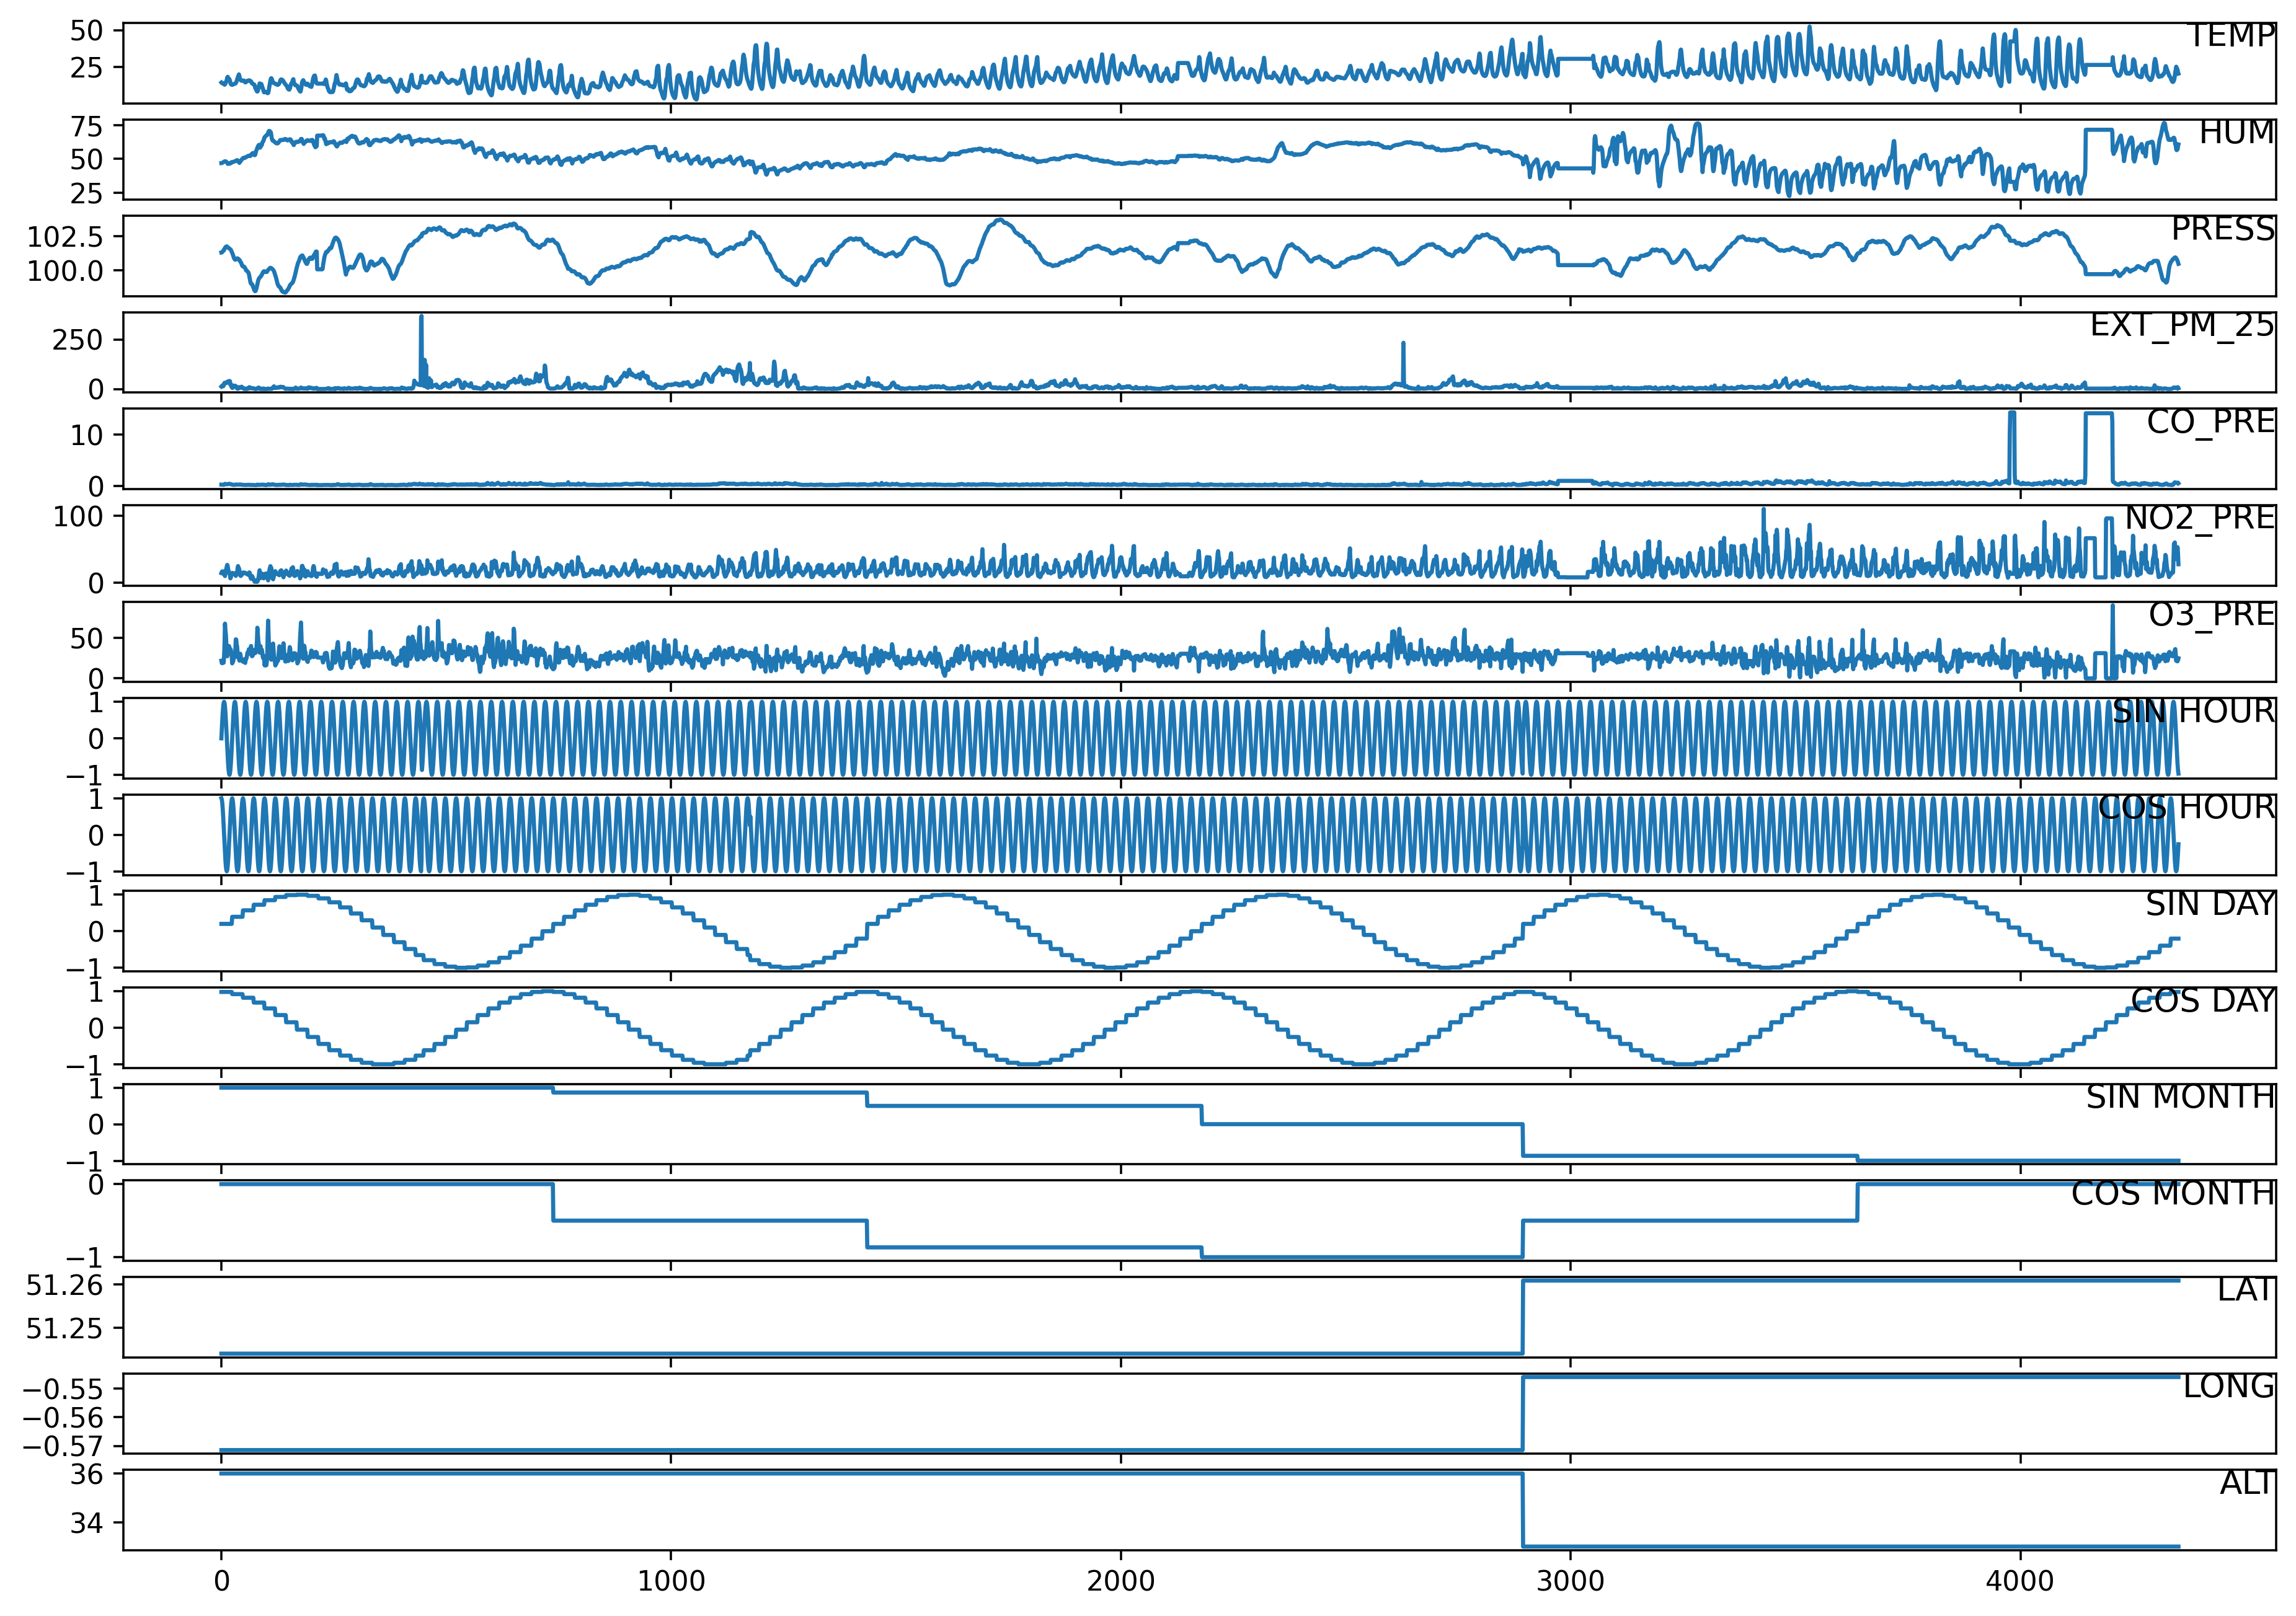

In [13]:
# load dataset
values = X_all.values
# specify columns to plot
groups = [i for i in range(len(X_all.columns))]
i = 1
# plot each column
plt.figure(figsize=(14,10), dpi=320, facecolor='w', edgecolor='k')
for group in groups:
    plt.subplot(len(groups), 1, i)
    plt.plot(values[:, group])
    plt.title(X_all.columns[group], y=0.5, loc='right')
    i += 1
plt.show()

In [14]:
X_all.max()

TEMP         5.249100e+01
HUM          7.654417e+01
PRESS        1.037557e+02
EXT_PM_25    3.686667e+02
CO_PRE       1.439311e+01
NO2_PRE      1.101329e+02
O3_PRE       9.032694e+01
SIN HOUR     1.000000e+00
COS HOUR     1.000000e+00
SIN DAY      9.987165e-01
COS DAY      1.000000e+00
SIN MONTH    1.000000e+00
COS MONTH    6.123234e-17
LAT          5.126085e+01
LONG        -5.460530e-01
ALT          3.600000e+01
dtype: float64

## Data Preprocessing

### Data Scaling

The feature map reads the data as a rotation on angle $\theta$, therefore we will scale our data on the range 0 to $2\pi$.

In [15]:
print("\nScaling Data\n")
scaler_x = MinMaxScaler(feature_range=(0, 1))
Xs_all  = scaler_x.fit_transform(X_all)
Xs_test = scaler_x.transform(X_test)


Scaling Data



In [16]:
print(Xs_all[0:5])

[[0.2333881  0.45133035 0.54737362 0.03345389 0.01115034 0.12087407
  0.24229695 0.5        1.         0.60077861 0.98973865 1.
  1.         0.         0.         1.        ]
 [0.22571913 0.45198728 0.54897846 0.04073237 0.01051252 0.13777143
  0.2089587  0.62940952 0.98296291 0.60077861 0.98973865 1.
  1.         0.         0.         1.        ]
 [0.22312935 0.45527808 0.55447195 0.04755877 0.01008943 0.14430137
  0.20845699 0.75       0.9330127  0.60077861 0.98973865 1.
  1.         0.         0.         1.        ]
 [0.22321635 0.45722111 0.56144682 0.05144665 0.00995316 0.14455447
  0.21116685 0.85355339 0.85355339 0.60077861 0.98973865 1.
  1.         0.         0.         1.        ]
 [0.22449451 0.46103005 0.56919326 0.03716094 0.0097643  0.13935328
  0.21507751 0.9330127  0.75       0.60077861 0.98973865 1.
  1.         0.         0.         1.        ]]


In [17]:
print(Xs_test[0:5])

[[0.37895452 0.51484871 0.5996852  0.00750452 0.00675747 0.10170549
  0.27091289 0.5        1.         0.60077861 0.98973865 0.25
  0.1339746  0.         0.         1.        ]
 [0.36083944 0.51485796 0.59755571 0.00809222 0.00508039 0.09910561
  0.27682374 0.62940952 0.98296291 0.60077861 0.98973865 0.25
  0.1339746  0.         0.         1.        ]
 [0.34631458 0.51520955 0.59737053 0.01044304 0.0046873  0.09526089
  0.28257034 0.75       0.9330127  0.60077861 0.98973865 0.25
  0.1339746  0.         0.         1.        ]
 [0.33038442 0.5148703  0.59712363 0.01179928 0.00441445 0.09168426
  0.28150109 0.85355339 0.85355339 0.60077861 0.98973865 0.25
  0.1339746  0.         0.         1.        ]
 [0.31906835 0.51708781 0.59767916 0.01225136 0.00421601 0.10371552
  0.28205224 0.9330127  0.75       0.60077861 0.98973865 0.25
  0.1339746  0.         0.         1.        ]]


### Spliting Train and Validation sets

In [18]:
print("\nSplitting Train Data\n")
train_ratio = 0.7
Xs_train, Xs_val, y_train, y_val = train_test_split(Xs_all, y_all, test_size=1 - train_ratio)


Splitting Train Data



In [19]:
print(f"There are {Xs_train.shape[1]} features and {Xs_train.shape[0]} instances in Train set")
print(f"There are {Xs_val.shape[1]} features and {Xs_val.shape[0]} instances in Val set")
print(f"There are {Xs_test.shape[1]} features and {Xs_test.shape[0]} instances in Test set")

There are 16 features and 3046 instances in Train set
There are 16 features and 1306 instances in Val set
There are 16 features and 1476 instances in Test set


## Quantum Layer

In [20]:
n_qubits = Xs_train.shape[1] # n_features
print(f"\nCircuit size: {n_qubits} qubits\n")


Circuit size: 16 qubits



In [21]:
weight_shapes = {"weights": (n_layers, n_qubits, 3)}
weight_shapes

{'weights': (2, 16, 3)}

In [22]:
def strong_entangling(inputs, weights):
    # weights: (n_layers,n_qubits,3)
    n_layers = len(weights)
    n_qubits = len(weights[0])
    
    ###############
    # Feature Map #
    ###############
    for idx in range(n_qubits):
        qml.Hadamard(wires=idx)
    qml.templates.AngleEmbedding(inputs, rotation='Y', wires=range(n_qubits))
    
    ##########
    # Ansatz #
    ##########
    for k in range(n_layers):
        # Variational Layer
        for i in range(len(weights[k])):
            qml.Rot(*weights[k][i],wires=i)

        # Entangling Layer
        for i in range(0, n_qubits-1): 
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[n_qubits-1, 0])
    
    ###############
    # Measurement #
    ###############
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]


In [23]:
def draw_circuit(qnn, n_qubits, weights):
    sampl_input = np.random.uniform(low=0, high=2*np.pi, size=(n_qubits))
    sampl_weights = np.random.uniform(low=0, high=np.pi, size=weights['weights'])
    params = np.concatenate((sampl_input, sampl_weights.flatten()))
    _ = qml.draw_mpl(strong_entangling, style="black_white")(sampl_input, sampl_weights)

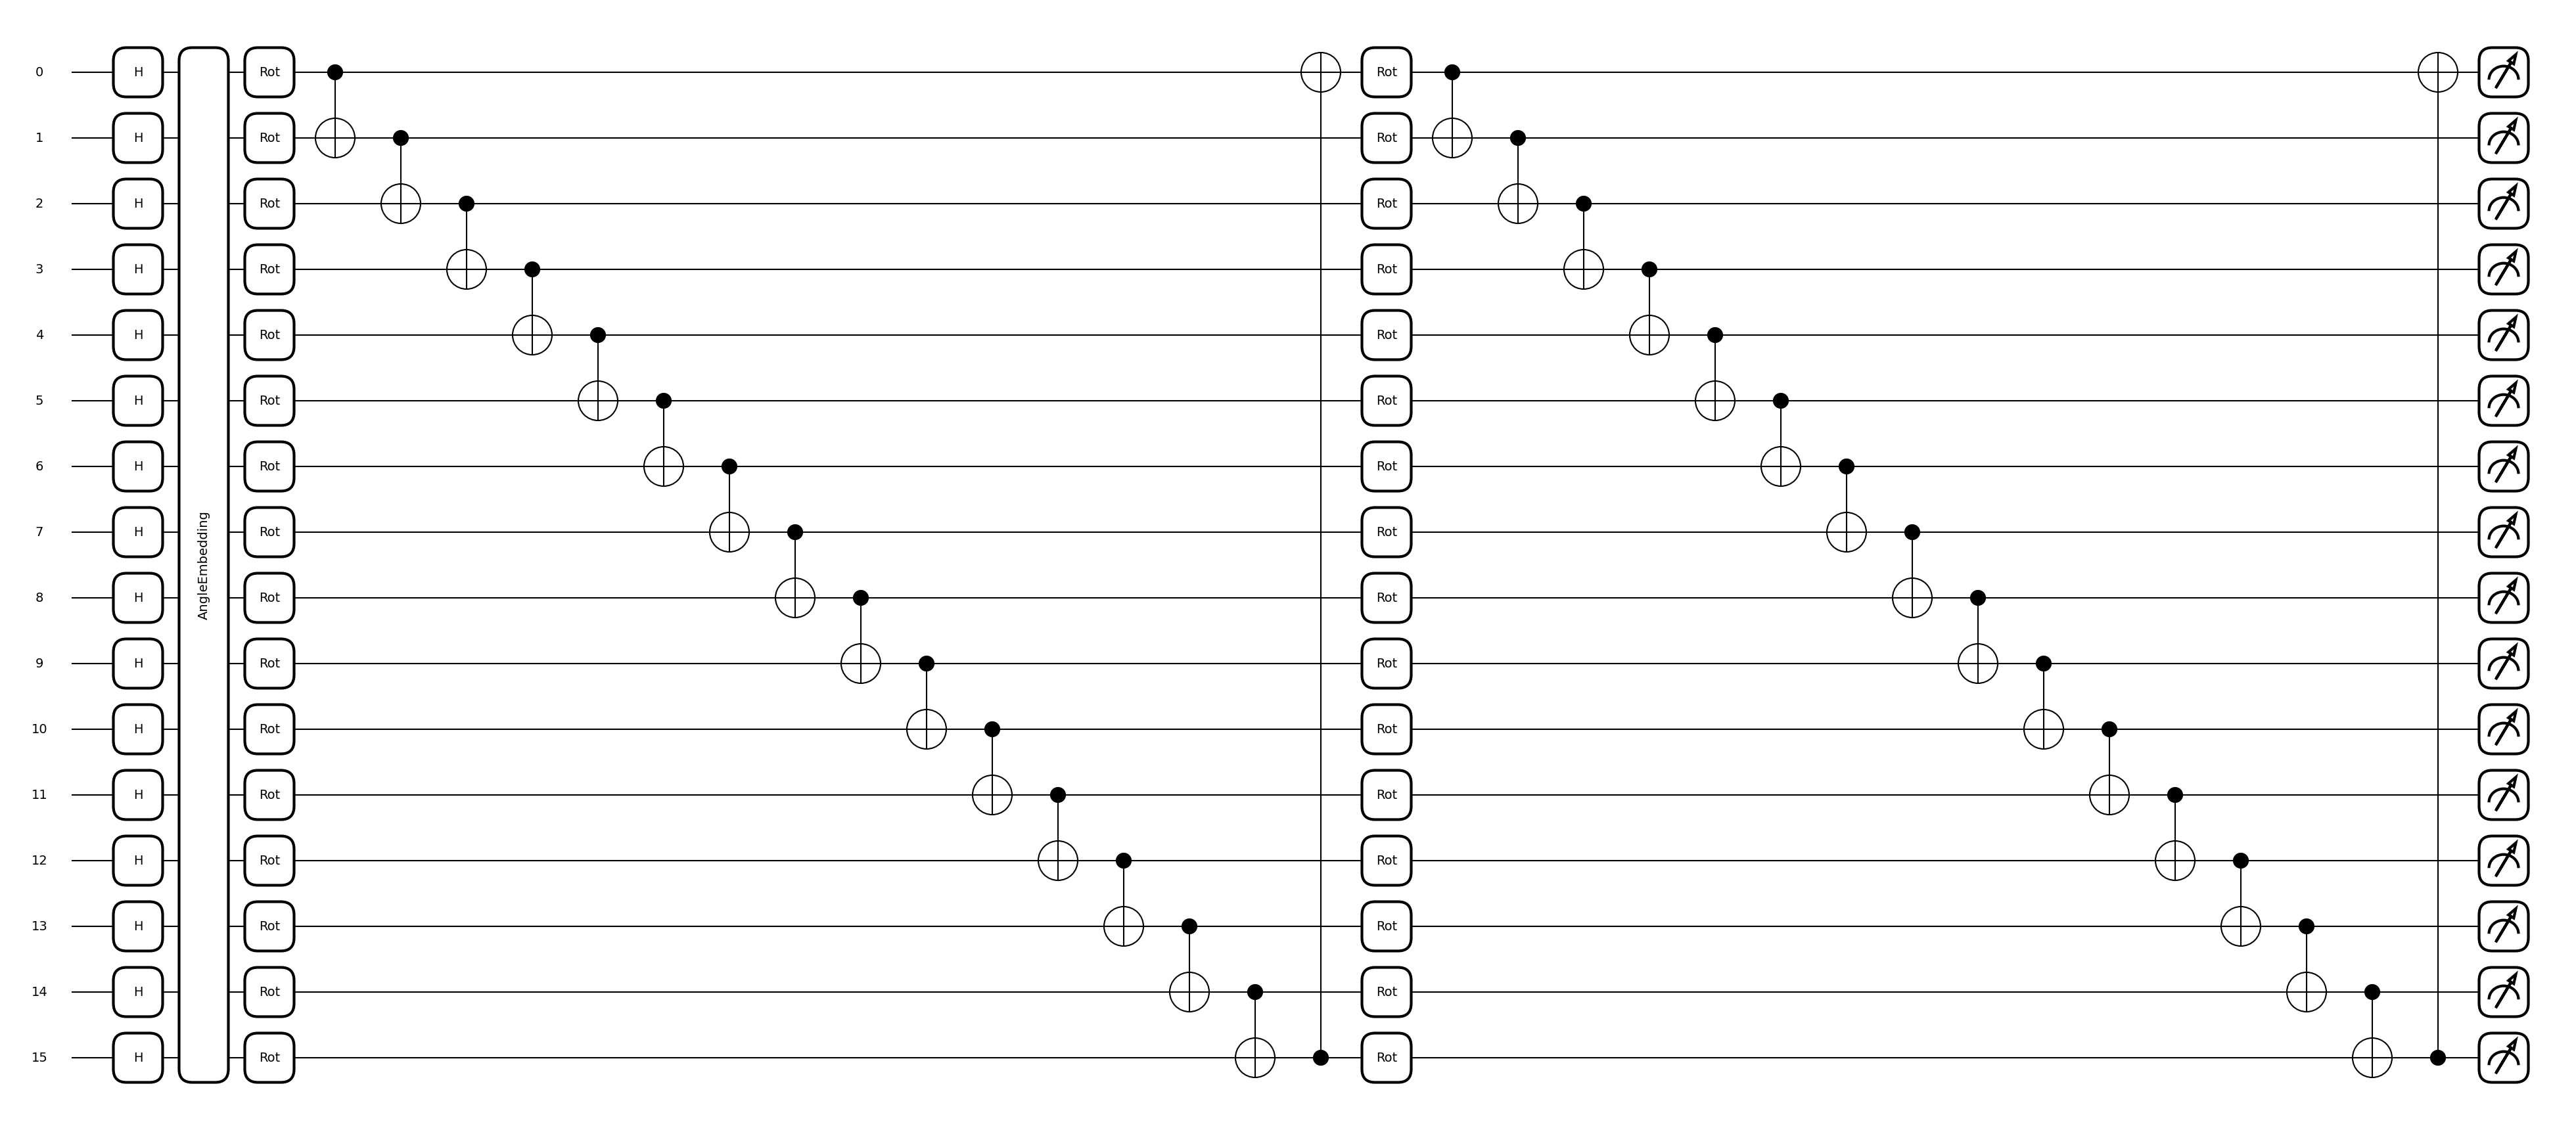

In [24]:
draw_circuit(strong_entangling, n_qubits, weight_shapes)

## Quantum Neural Network

In [25]:
def create_quantum_model(n_qubits, weights, prev):
    input_layer = tf.keras.layers.Input(shape=(n_qubits,))

    dev = qml.device("default.qubit", wires=n_qubits)
    qnn = qml.QNode(strong_entangling, dev, interface="tf")
    q_layer = qml.qnn.KerasLayer(qnn, weights, output_dim=n_qubits)

    activation=tf.keras.layers.Activation(tf.keras.activations.relu)
    #output_layer = tf.keras.layers.Dense(len(prev), LeakyReLU(alpha=0.01))
    output_layer = tf.keras.layers.Dense(len(prev), kernel_initializer='normal')

    model = tf.keras.models.Sequential([
        input_layer
        , q_layer
        , activation
        , output_layer])
    
    opt = tf.keras.optimizers.Adam(learning_rate = 0.001)
    
    model.compile(loss=['mse'], optimizer=opt, metrics=['mae'])
    
    return model

In [26]:
model = create_quantum_model(n_qubits, weight_shapes, prevision_window)
input_shape = (n_qubits,)
model.build(input_shape)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 16)                96        
                                                                 
 activation (Activation)     (None, 16)                0         
                                                                 
 dense (Dense)               (None, 6)                 102       
                                                                 
Total params: 198
Trainable params: 198
Non-trainable params: 0
_________________________________________________________________


2026-02-04 11:50:18.476257: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-04 11:50:20.531184: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 30974 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:30:00.0, compute capability: 7.0


## Training

After the model is created we start the training

In [27]:
es=EarlyStopping(monitor='val_loss', min_delta=0, patience=6, verbose=0, mode='auto', baseline=None, restore_best_weights=True)

checkpoint_path = os.path.join('checkpoint', SUBDIR, f"cp-{ansatz}-lookback-{lookback}-depth-{n_layers}-"+"{epoch:04d}.ckpt")
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

# Create a callback that saves the model's weights
n_batches = len(Xs_train) / batch_size
n_batches = int(np.ceil(n_batches))
cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path
                                                    , save_weights_only=True
                                                    , verbose=0
                                                    , save_freq=n_batches)

history_model = model.fit(Xs_train, y_train
                       , epochs=100, batch_size=batch_size
                       , verbose=1
                       , validation_data=(Xs_val, y_val)
                       , callbacks = [cp_callback])

Epoch 1/100
24/24 [==============================] - 71s 3s/step - loss: 549.7878 - mae: 13.1816 - val_loss: 593.5670 - val_mae: 13.7436
Epoch 2/100
24/24 [==============================] - 70s 3s/step - loss: 549.1454 - mae: 13.1574 - val_loss: 592.8793 - val_mae: 13.7190
Epoch 3/100
24/24 [==============================] - 70s 3s/step - loss: 548.4669 - mae: 13.1324 - val_loss: 592.1370 - val_mae: 13.6926
Epoch 4/100
24/24 [==============================] - 70s 3s/step - loss: 547.6979 - mae: 13.1042 - val_loss: 591.2490 - val_mae: 13.6614
Epoch 5/100
24/24 [==============================] - 69s 3s/step - loss: 546.7213 - mae: 13.0688 - val_loss: 590.0614 - val_mae: 13.6201
Epoch 6/100
24/24 [==============================] - 69s 3s/step - loss: 545.3502 - mae: 13.0204 - val_loss: 588.3769 - val_mae: 13.5622
Epoch 7/100
24/24 [==============================] - 69s 3s/step - loss: 543.4479 - mae: 12.9520 - val_loss: 586.0441 - val_mae: 13.4823
Epoch 8/100
24/24 [======================

### Plotting Loss

Saving history in /home/otto.pires/dynex-poc/plots/Kuatomu-Ansatz-QNN-Lookback-1-Depth-2/loss-history-pollution-QNN-2-layers-lookback-1-batch-128.png


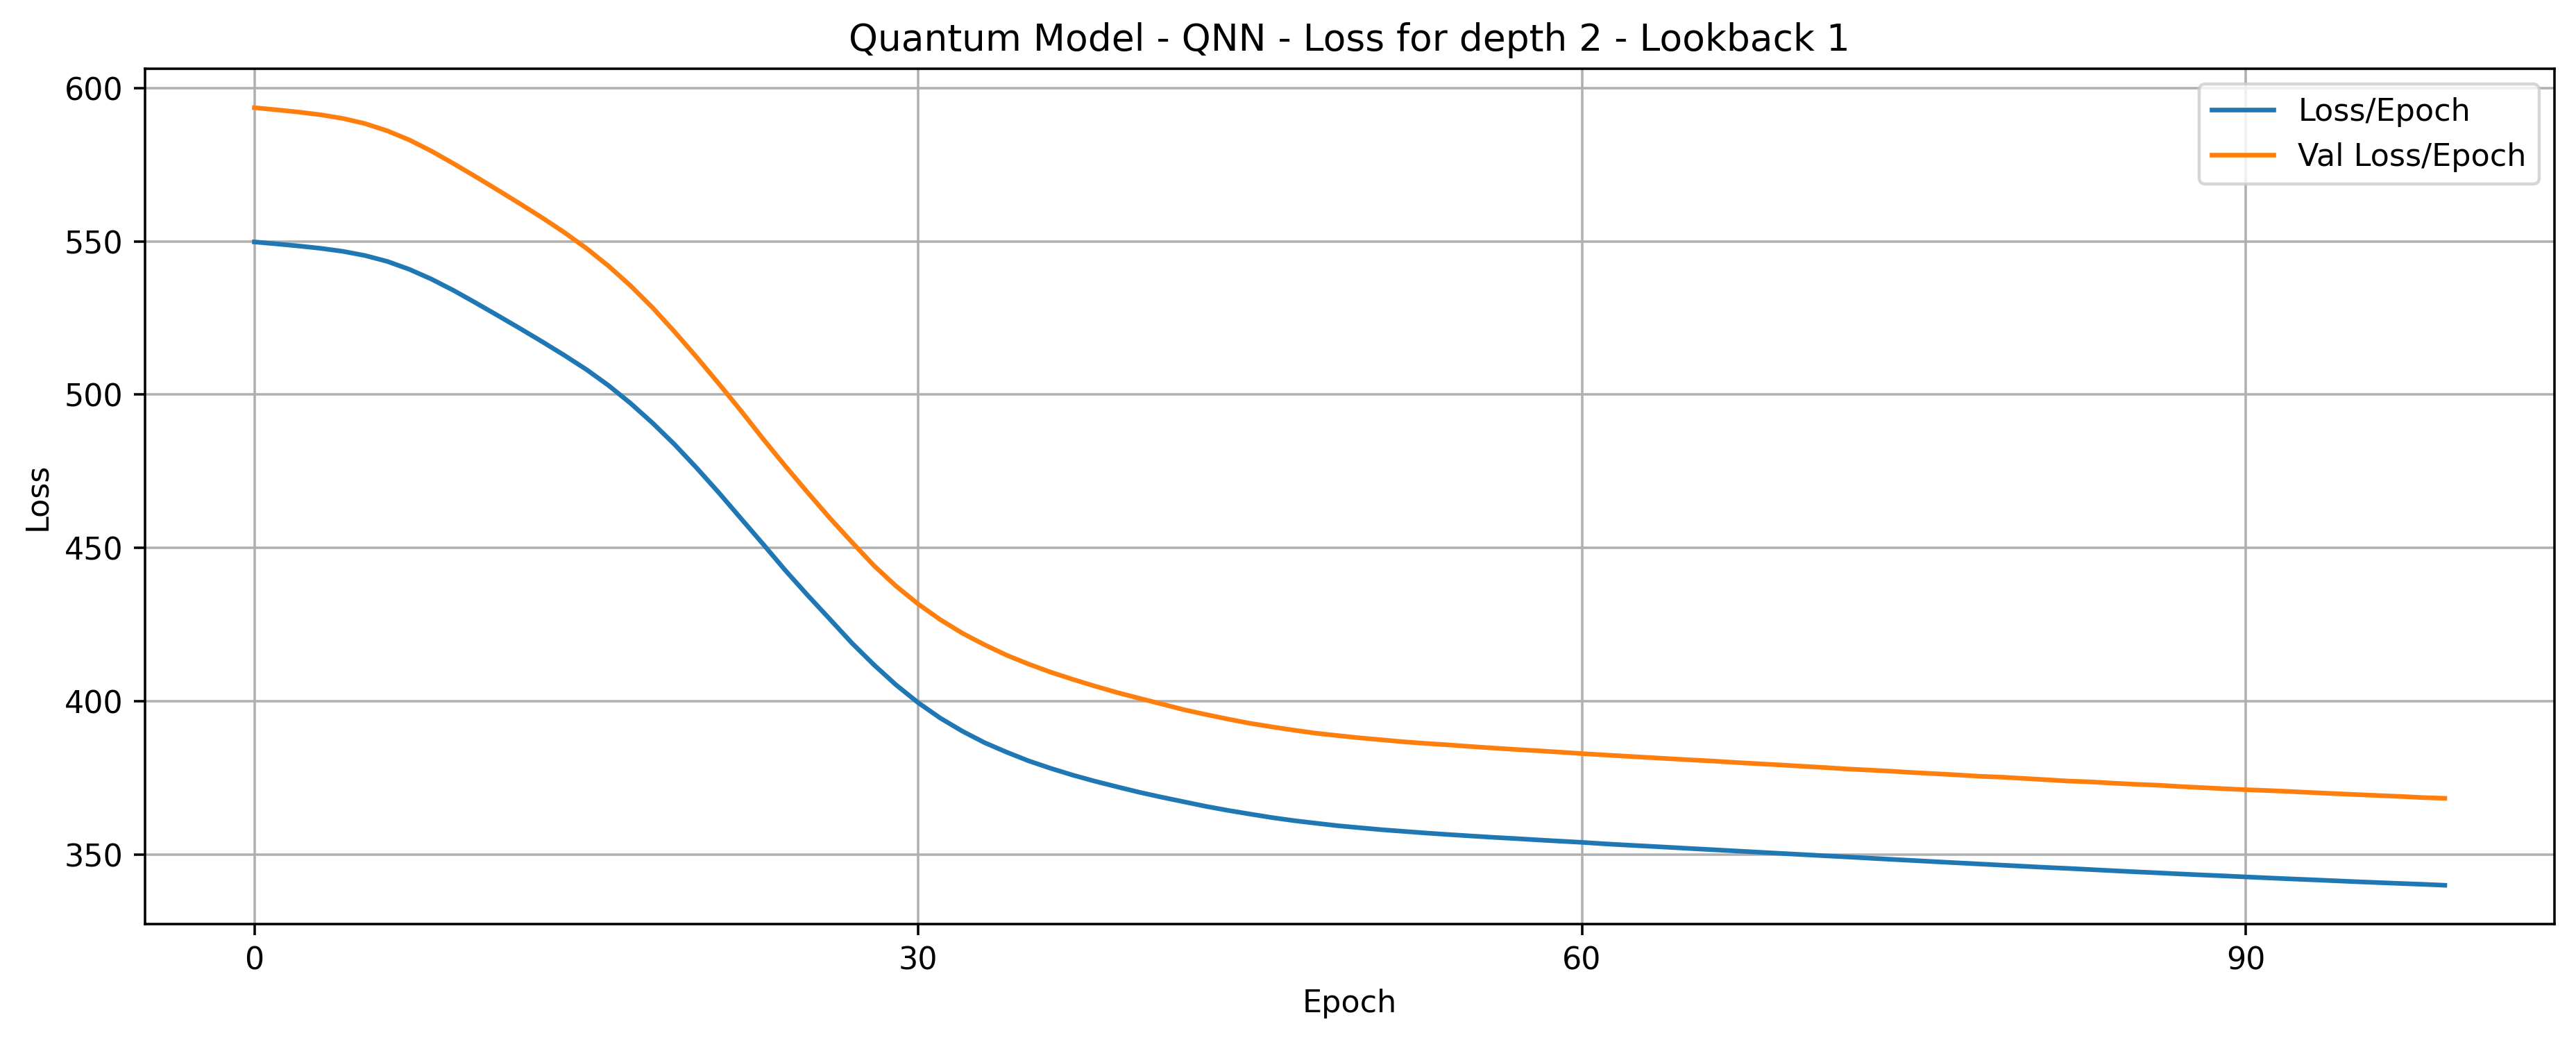

In [28]:
plot_history(n_layers, history_model, ansatz, lookback, batch_size)

## Prediction

Prediction intervals were estimated using quantile regression applied to the errors of predictions made in the test dataset. These intervals were computed for 1 hour ahead.

In [29]:
path_an = os.path.abspath(os.path.join(os.getcwd(), 'analysis', SUBDIR))
os.makedirs(path_an, exist_ok=True)  

In [30]:
y_pred = model.predict(Xs_test,verbose=0)
mean_predictions, mean_error_normal, mean_error_left_normal, mean_error_right_normal = get_mean_left_right_error_interval(model, Xs_val, y_val, y_test, y_pred)

41/41 [==============================] - 39s 939ms/step


In [31]:
error_interval = [[str(i+1)+" hours"
                              , mean_predictions[0][i]
                              , mean_error_normal[0][i]
                              , mean_error_left_normal[0][i]
                              , mean_error_right_normal[0][i]
                          ] for i in range(len(mean_predictions[0]))
                         ]
pred_interval = pd.DataFrame(error_interval)
pred_interval.columns = ['Index', 'Mean Pred', 'Error Normal', 'Error Left', 'Error Right']
pred_interval = pred_interval.set_index('Index')
pred_interval.loc['Mean'] = pred_interval.mean()

pred_interval

,Mean Pred,Error Normal,Error Left,Error Right
Index,,,,
1 hours,11.336414,32.151363,-20.814950,43.487777
2 hours,11.361078,32.408836,-21.047758,43.769914
3 hours,11.429537,31.863544,-20.434008,43.293081
4 hours,11.355217,33.371067,-22.015849,44.726285
5 hours,11.241605,37.199051,-25.957446,48.440656
6 hours,11.182305,40.673248,-29.490944,51.855553
Mean,11.317693,34.611185,-23.293492,45.928878


In [32]:
filename = f"pred_interval-{ansatz}-lookback-{lookback}-batch-{batch_size}-depth-{n_layers}.csv"
print(f"Saving Pred Interval in {os.path.join(path_an,filename)}")
pred_interval.to_csv(os.path.join(path_an,filename), index=False)

Saving Pred Interval in /home/otto.pires/dynex-poc/analysis/Kuatomu-Ansatz-QNN-Lookback-1-Depth-2/pred_interval-QNN-lookback-1-batch-128-depth-2.csv


Saving Prediction Plot in /home/otto.pires/dynex-poc/plots/Kuatomu-Ansatz-QNN-Lookback-1-Depth-2/prediction-pollution-QNN-2-layers-lookback-1-batch-128-1-hours.png


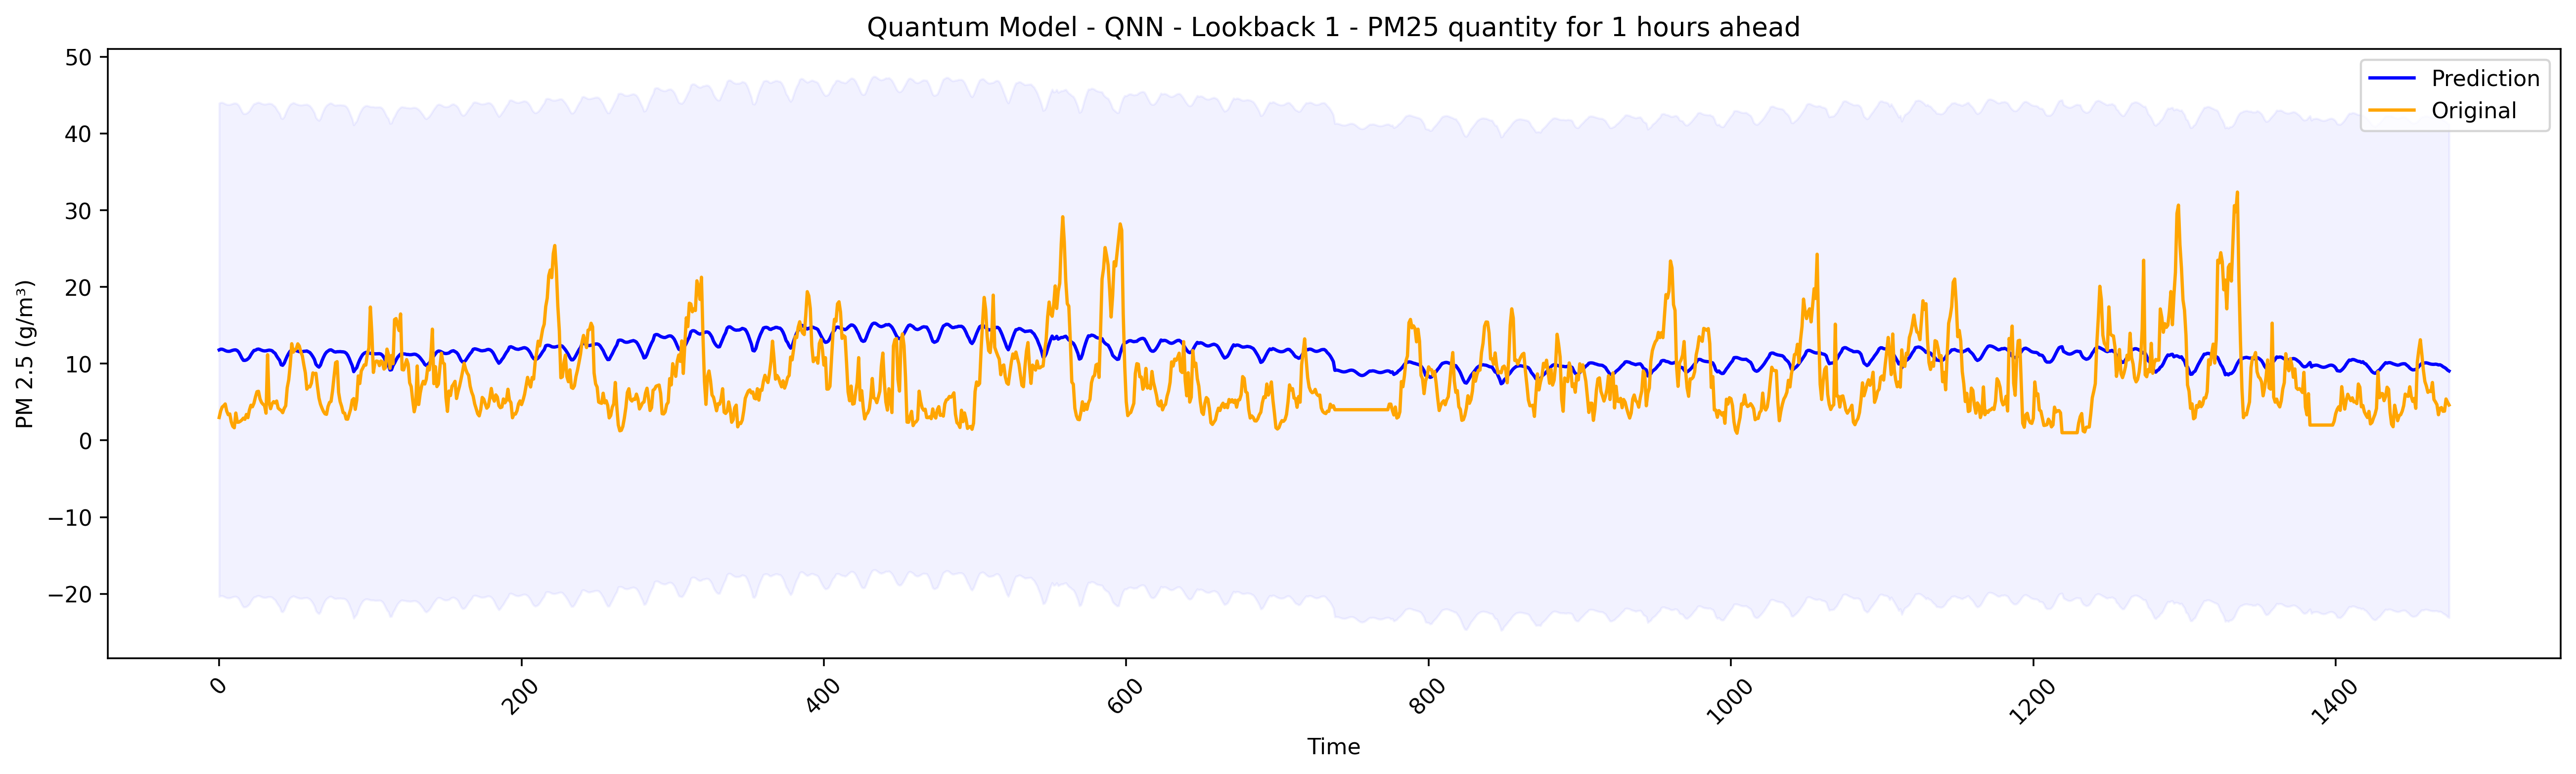

Saving Prediction Plot in /home/otto.pires/dynex-poc/plots/Kuatomu-Ansatz-QNN-Lookback-1-Depth-2/prediction-pollution-QNN-2-layers-lookback-1-batch-128-2-hours.png


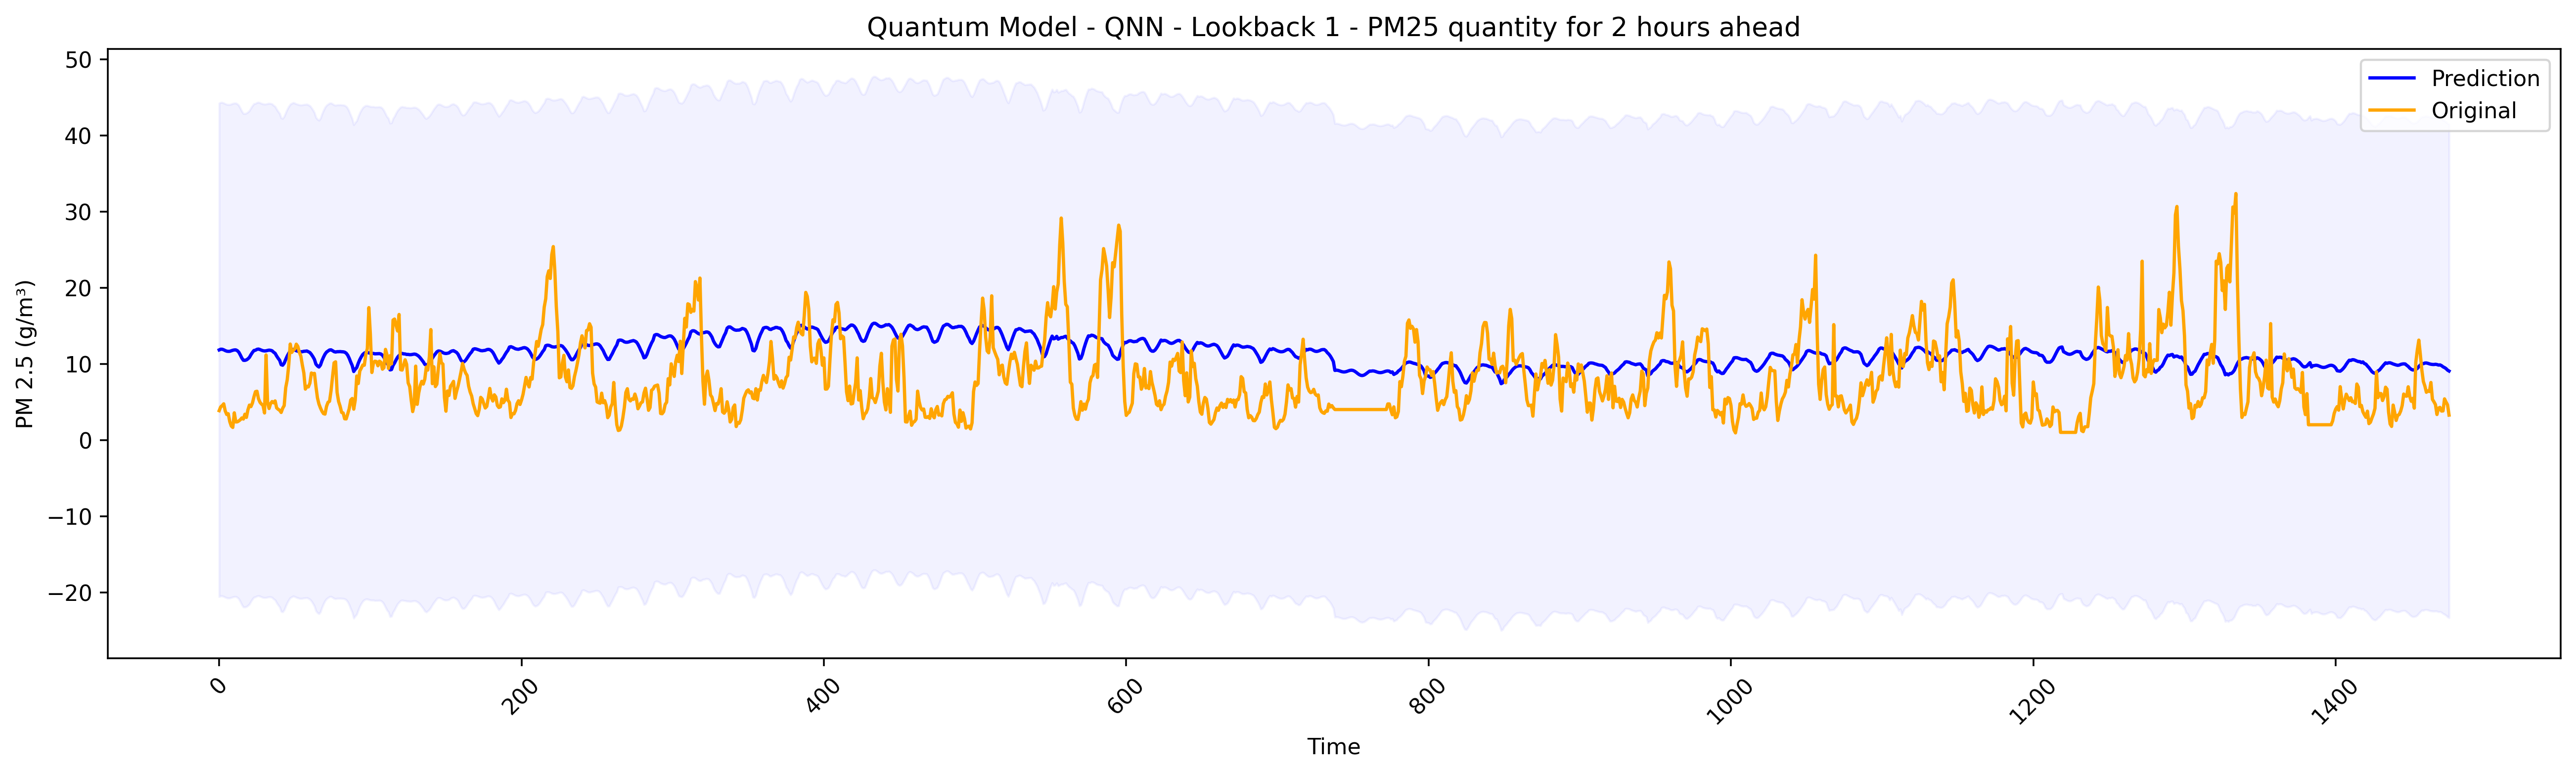

Saving Prediction Plot in /home/otto.pires/dynex-poc/plots/Kuatomu-Ansatz-QNN-Lookback-1-Depth-2/prediction-pollution-QNN-2-layers-lookback-1-batch-128-3-hours.png


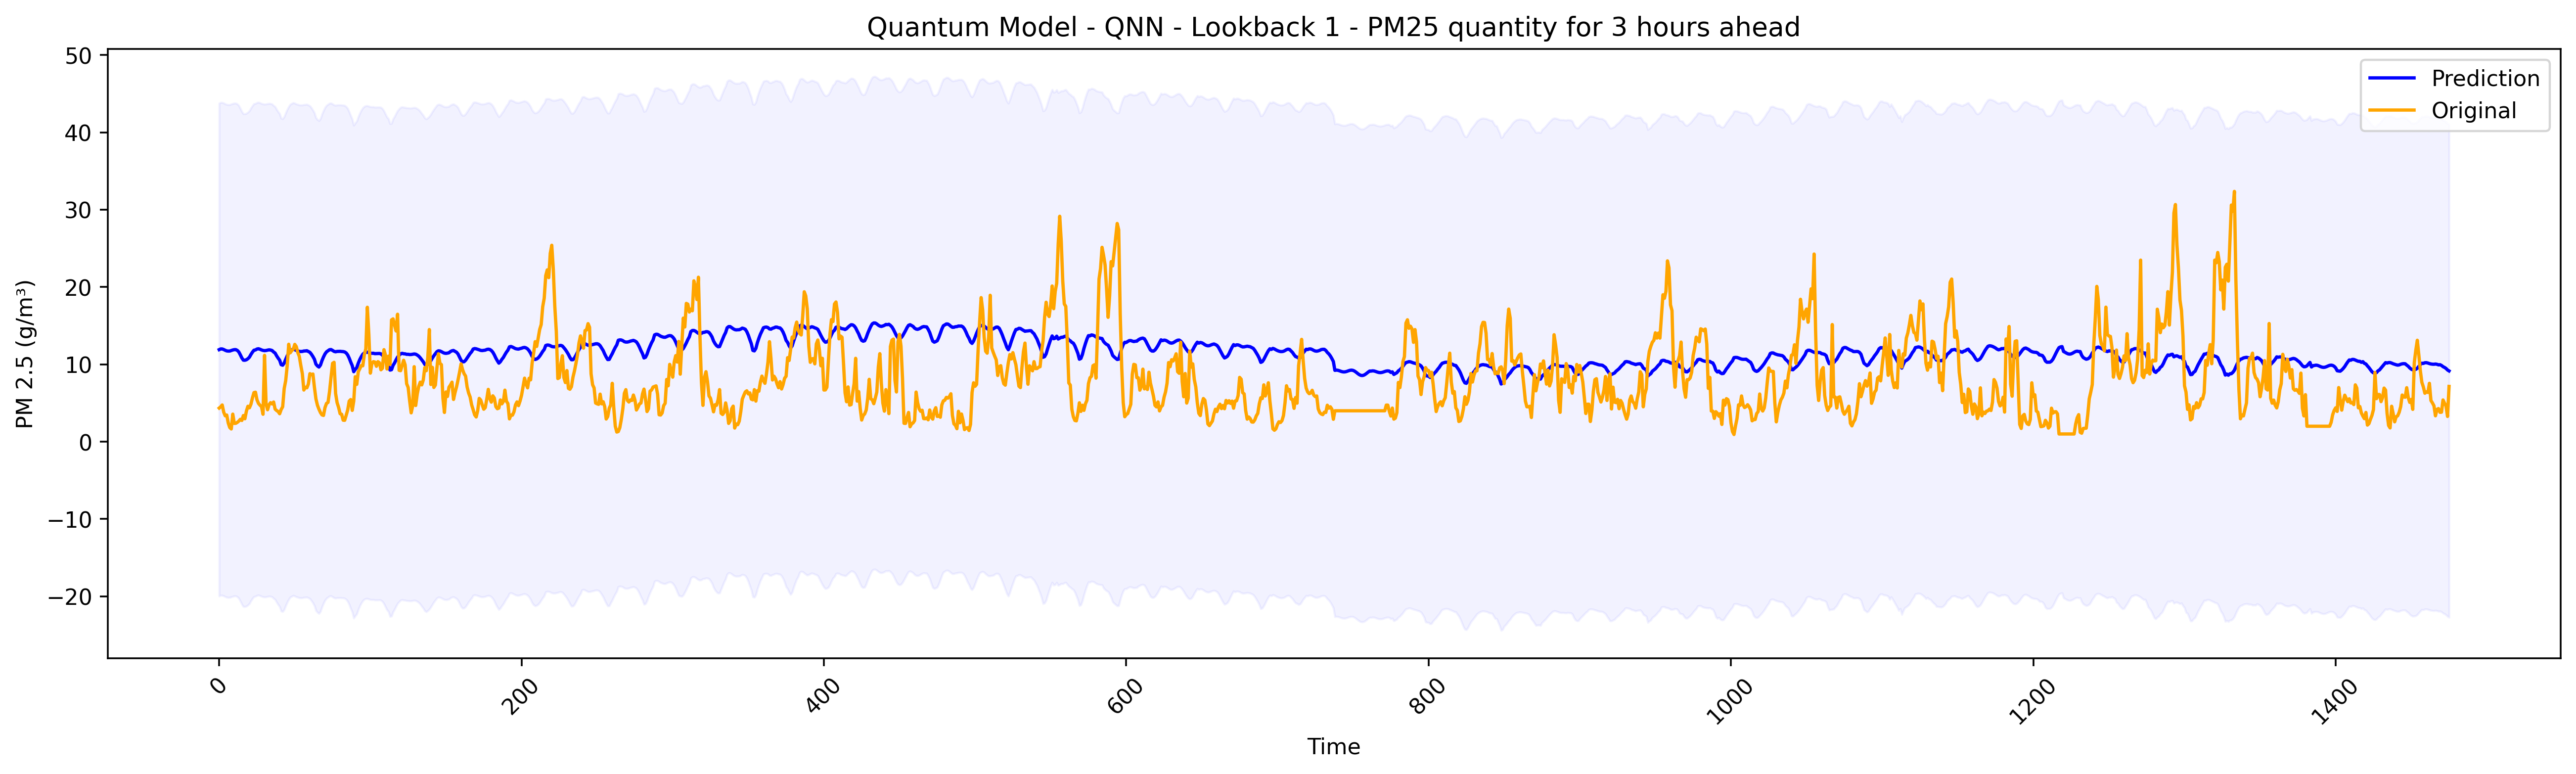

Saving Prediction Plot in /home/otto.pires/dynex-poc/plots/Kuatomu-Ansatz-QNN-Lookback-1-Depth-2/prediction-pollution-QNN-2-layers-lookback-1-batch-128-4-hours.png


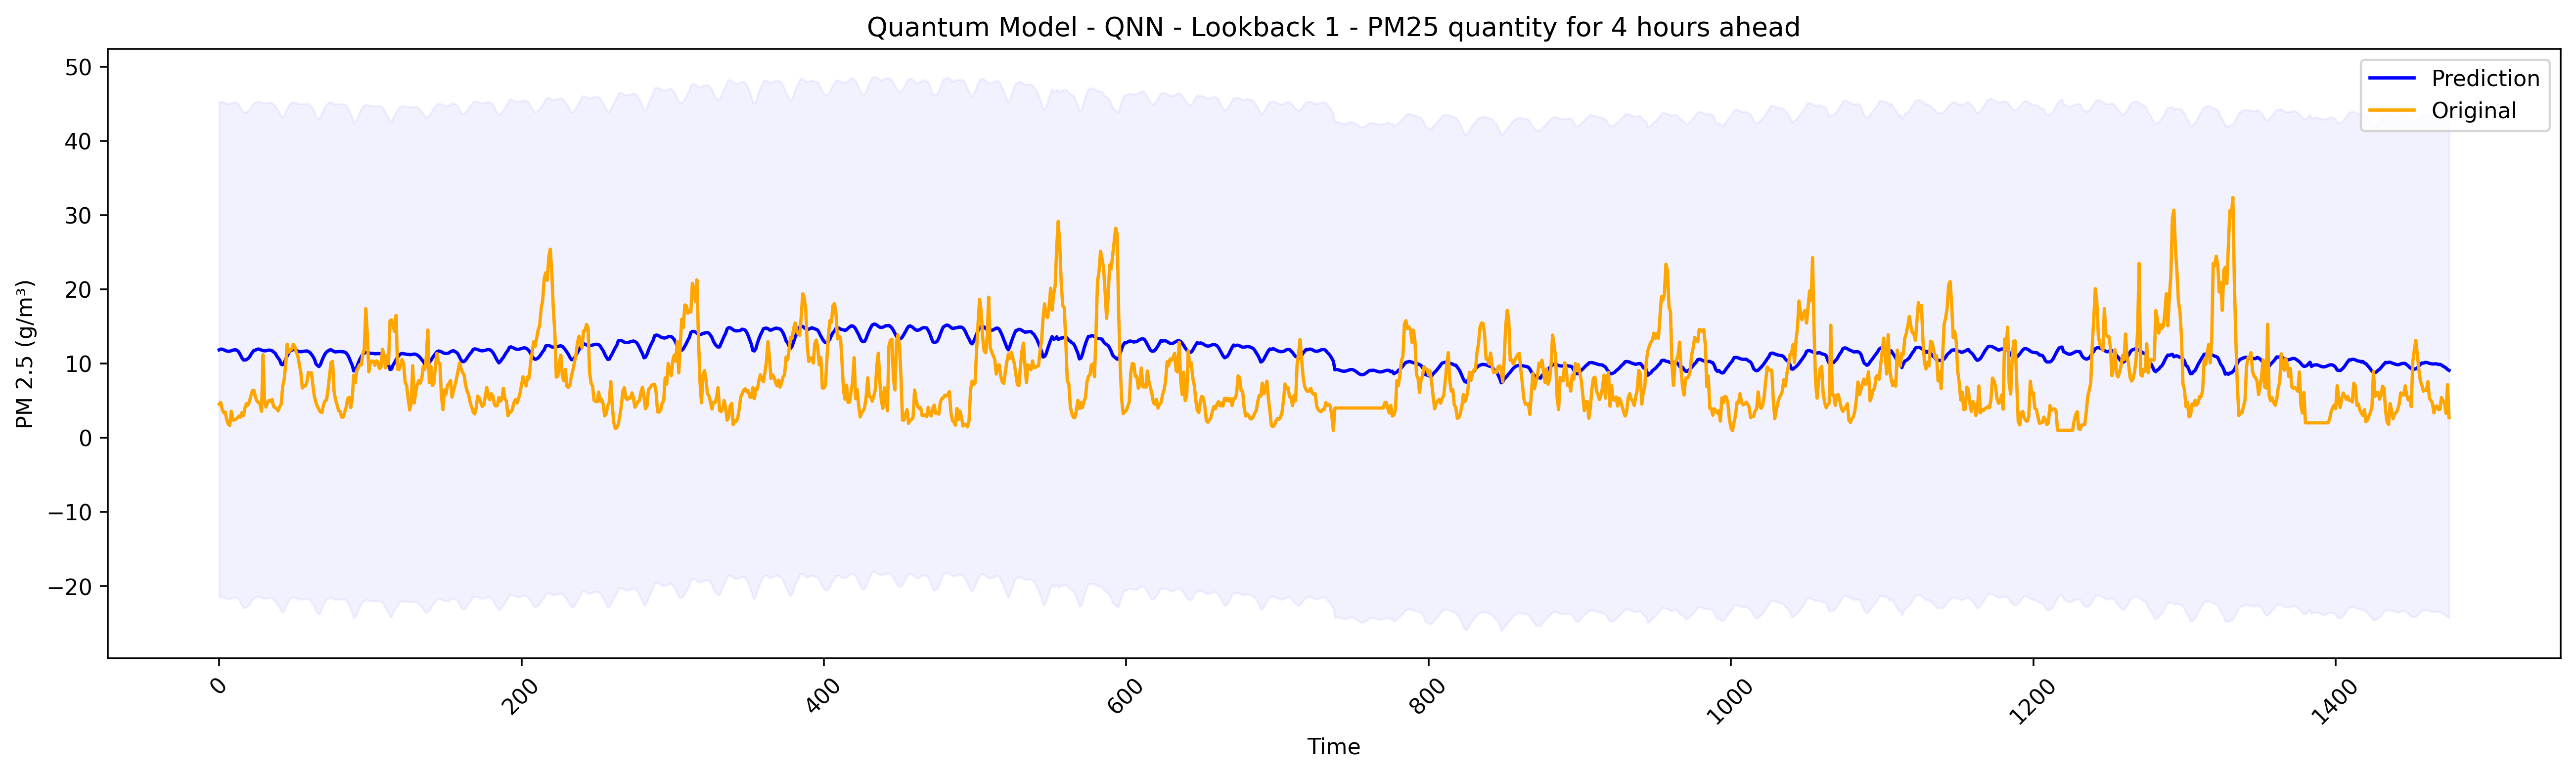

Saving Prediction Plot in /home/otto.pires/dynex-poc/plots/Kuatomu-Ansatz-QNN-Lookback-1-Depth-2/prediction-pollution-QNN-2-layers-lookback-1-batch-128-5-hours.png


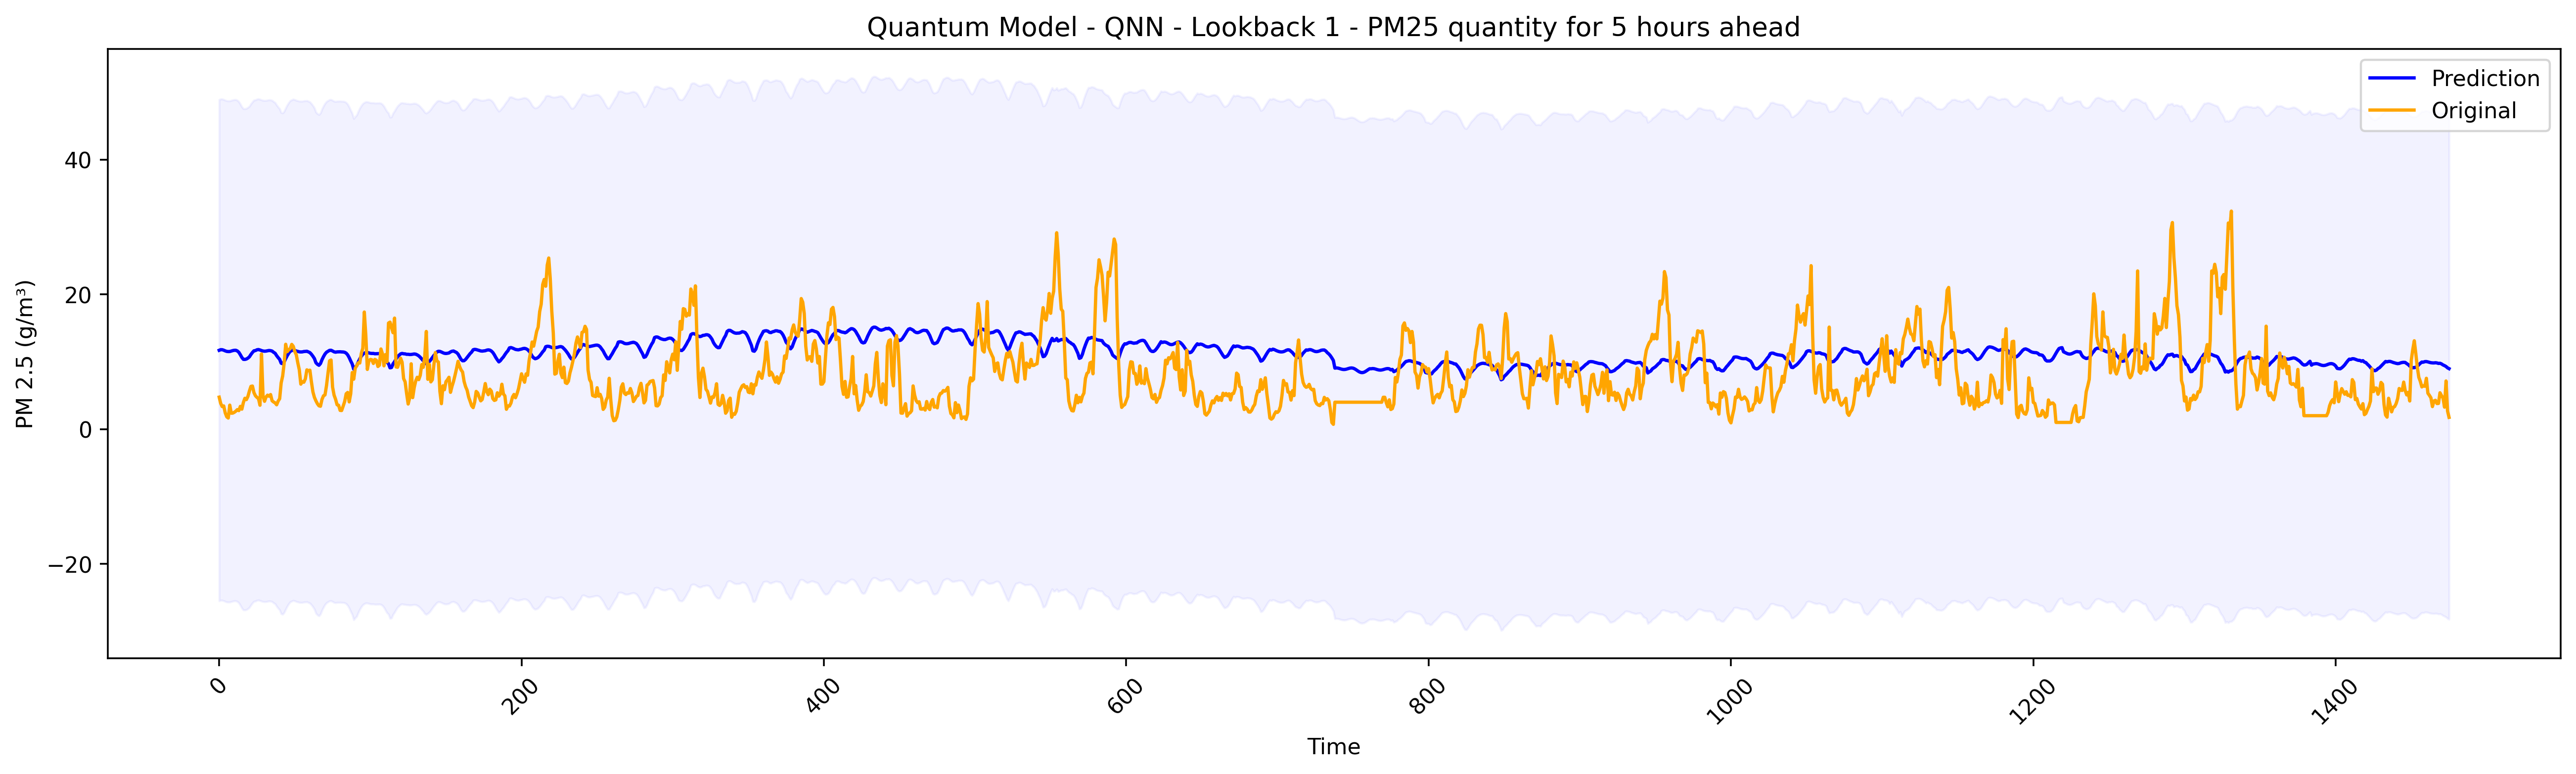

Saving Prediction Plot in /home/otto.pires/dynex-poc/plots/Kuatomu-Ansatz-QNN-Lookback-1-Depth-2/prediction-pollution-QNN-2-layers-lookback-1-batch-128-6-hours.png


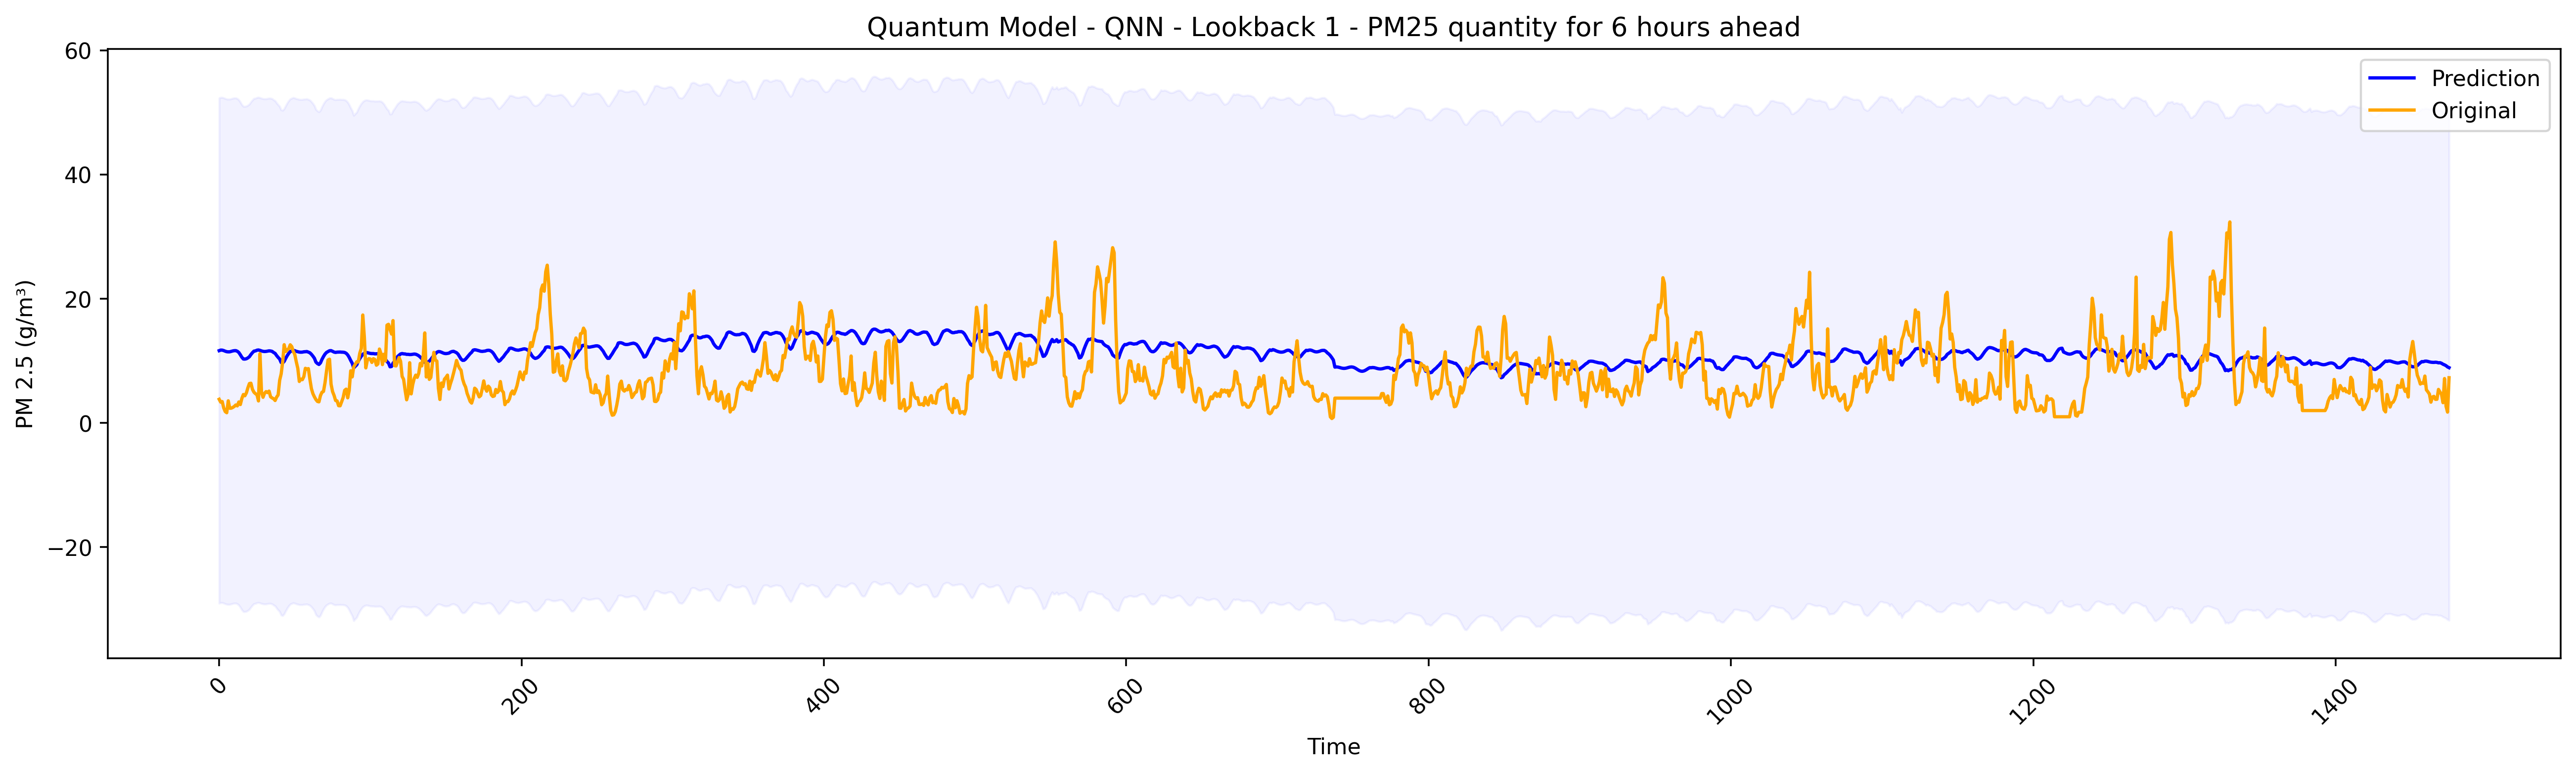

In [33]:
plot_prediction_versus_observed(n_layers, y_test, y_pred, mean_error_normal, ansatz, lookback, batch_size, prevision_window)

## Statistical Analysis

The evaluation of our proposed Quantum Machine Learning (QML) method involved a comprehensive analysis of various performance metrics applied to both training and test datasets. These metrics included mean square error (MSE), mean absolute error (MAE), and normalized mean square error (NMSE), along with the Pearson correlation coefficient (r)

In [34]:
all_analysis = quantitative_analysis(y_test, y_pred)
all_analysis


1 hours ahead
MAE: 5.221680470081526
MSE: 37.82431679767918
NMSE: 1.4838113188195627
RMSE: 6.15014770535466
NRMSE: 1.2181179412600256
R: 0.0817337245374134
R²: -0.4848172925950336
Fator de 2: 0.5731707

2 hours ahead
MAE: 5.256782879911248
MSE: 38.172995012557784
NMSE: 1.4976683429448745
RMSE: 6.178429817725356
NRMSE: 1.2237926061816498
R: 0.07257830027972892
R²: -0.49868371131297295
Fator de 2: 0.5799458

3 hours ahead
MAE: 5.3140701361141875
MSE: 38.77563107368934
NMSE: 1.521581564718735
RMSE: 6.227008196051242
NRMSE: 1.2335240430241865
R: 0.06084677761855209
R²: -0.522613145440578
Fator de 2: 0.5833333

4 hours ahead
MAE: 5.294177152923129
MSE: 38.50506338630441
NMSE: 1.509023053366552
RMSE: 6.205244828876973
NRMSE: 1.2284229944797322
R: 0.05156874925772048
R²: -0.5100461198434105
Fator de 2: 0.58468837

5 hours ahead
MAE: 5.249801756760615
MSE: 37.901219822386686
NMSE: 1.4828213986187353
RMSE: 6.156396658954545
NRMSE: 1.2177115416299278
R: 0.0440856193380043
R²: -0.483826701261866

,MAE,MSE,NMSE,RMSE,NRMSE,R,R²,Fator de 2
Index,,,,,,,,
1 hours,5.221680,37.824317,1.483811,6.150148,1.218118,0.081734,-0.484817,0.573171
2 hours,5.256783,38.172995,1.497668,6.178430,1.223793,0.072578,-0.498684,0.579946
3 hours,5.314070,38.775631,1.521582,6.227008,1.233524,0.060847,-0.522613,0.583333
4 hours,5.294177,38.505063,1.509023,6.205245,1.228423,0.051569,-0.510046,0.584688
5 hours,5.249802,37.901220,1.482821,6.156397,1.217712,0.044086,-0.483827,0.587398
6 hours,5.238076,37.713309,1.474525,6.141116,1.214300,0.035703,-0.475524,0.588753
Média,5.262431,38.148756,1.494905,6.176391,1.222645,0.057753,-0.495919,0.582882


In [35]:
filename = f"metrics-{ansatz}-lookback-{lookback}-batch-{batch_size}-depth-{n_layers}.csv"
print(f"Saving Metrics in {os.path.join(path_an, filename)}")
all_analysis.to_csv(os.path.join(path_an, filename))

print("\n#########\n")

Saving Metrics in /home/otto.pires/dynex-poc/analysis/Kuatomu-Ansatz-QNN-Lookback-1-Depth-2/metrics-QNN-lookback-1-batch-128-depth-2.csv

#########

